In [1]:
import scanpy as sc 
import muon as mu 
import numpy as np 
import pandas as pd 

In [26]:
mdata = mu.read_h5mu("/home/rsun@ZHANGroup.local/solid-recover/data/multi_omics/mus_kidney_sex/train.h5mu")
mdata

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 101581 × 118760
  var:	'n_cells'
  2 modalities
    rna_count:	101581 x 13050
      obs:	'sample_id', 'nCount_RNA', 'nFeature_RNA', 'Age', 'Nuclei_Dissociation_Date', 'celltype_final', 'celltype_final_fullname', 'tissue_type', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'gene_symbols', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
      uns:	'batch_condition', 'citation', 'default_embedding', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
      obsm:	'X_embed_sr_ckpt_10000', 'X_embed_sr_ckpt_2000', 'X_embed_sr_ckpt_4000', 'X_embed_sr_ckpt_6000', 'X_embed_sr_ckpt_8000', 'X_pca', 'X_umap', 'X_umap_sr_ckpt_10000', 'X_umap_sr_ckpt_2000', 'X_umap_sr_ckpt_4000', 'X_umap_sr_ckpt_6000', 'X_umap_sr_ckpt_8000'
    atac_count:	101581 x 105710
      obs:	'n_fragment', 'frac_dup', 'frac_mito', 'cell_type'
      var:	'n_cells'
      uns:	'log1p'
      obsm:	'X_embed_sr_ckpt_10000', 'X_embed_sr_ckpt_2000', 'X_embed_sr_ckpt_4000', 'X_embed_sr_ckpt_6000', 'X_embed_sr_ckpt_8000'

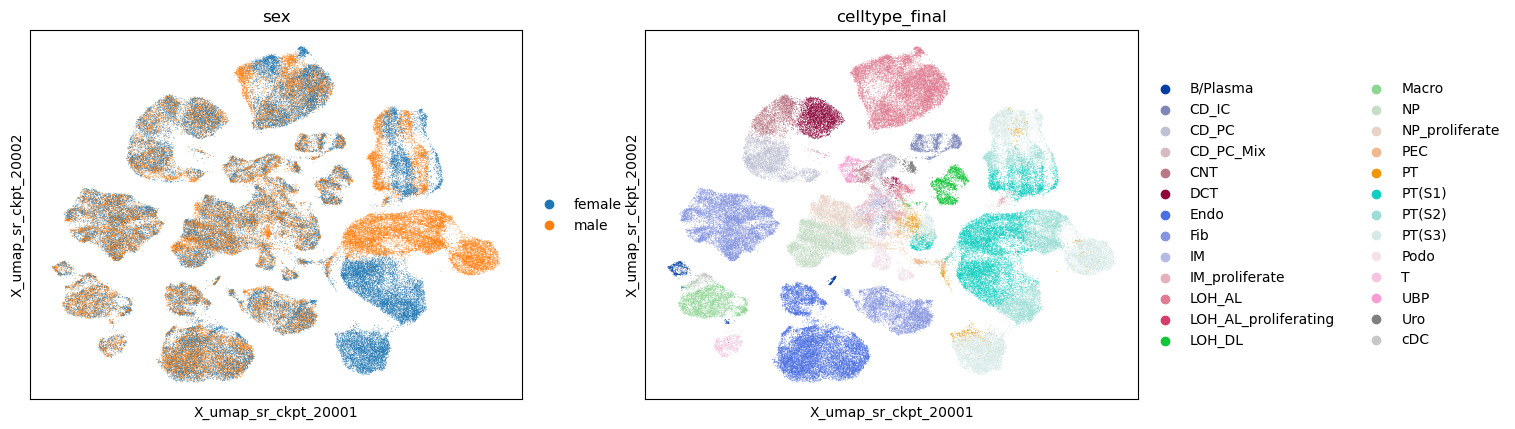

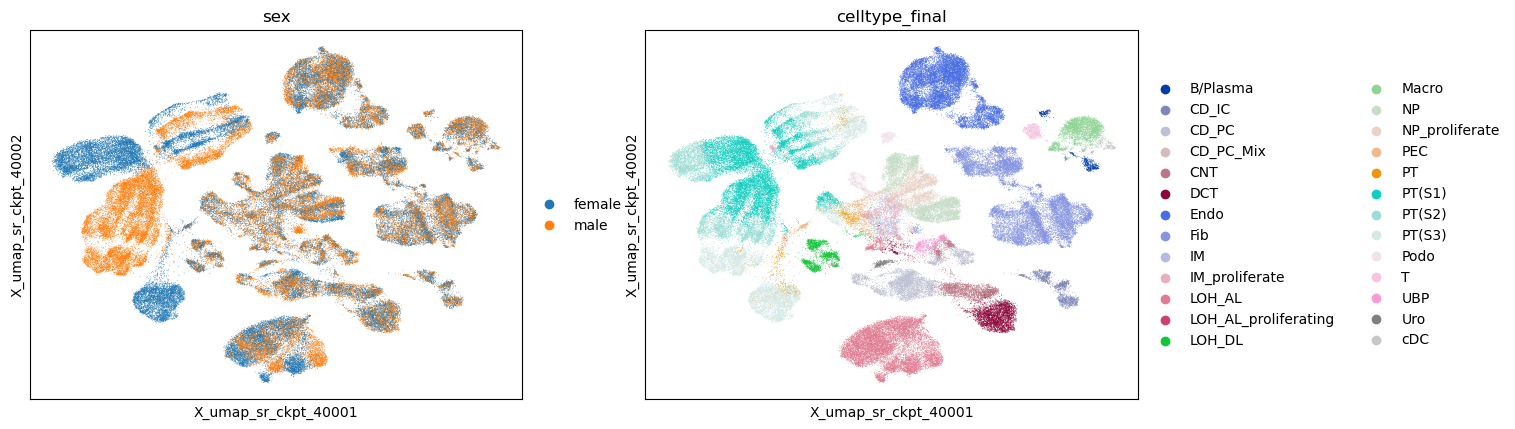

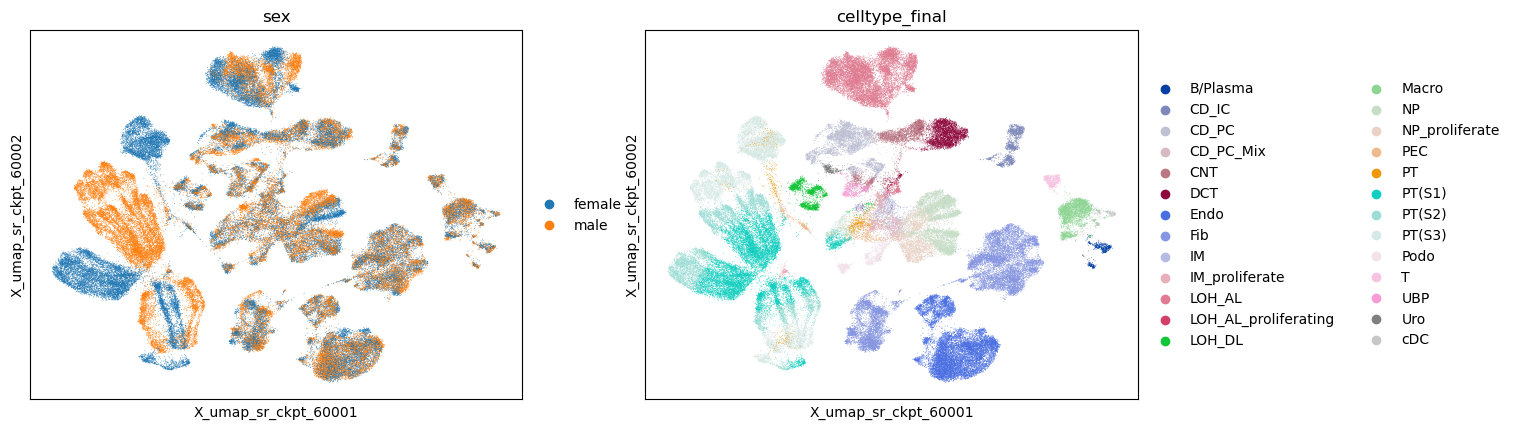

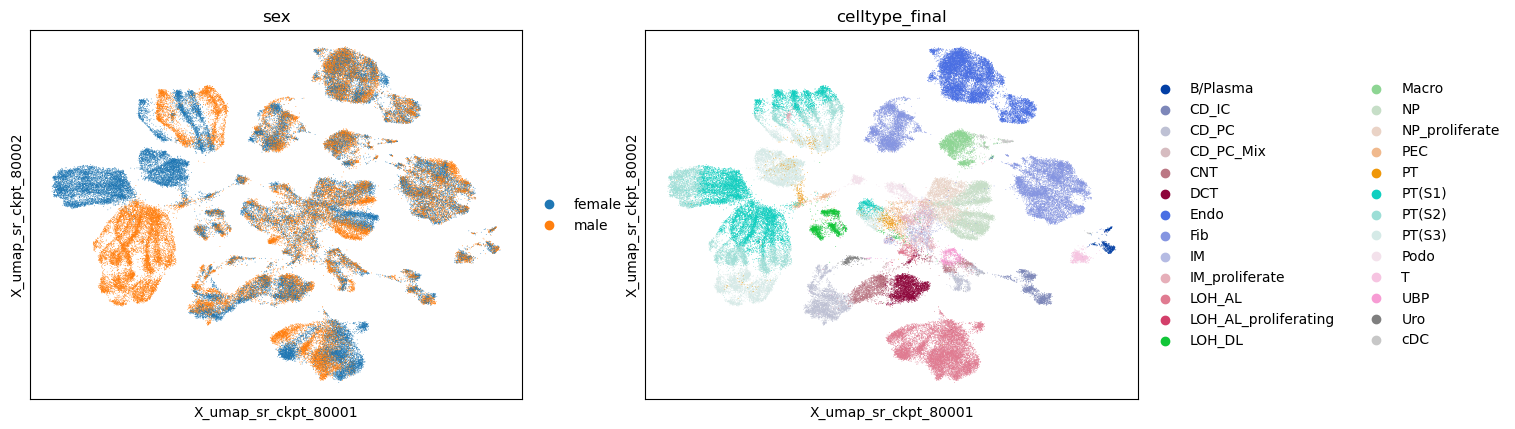

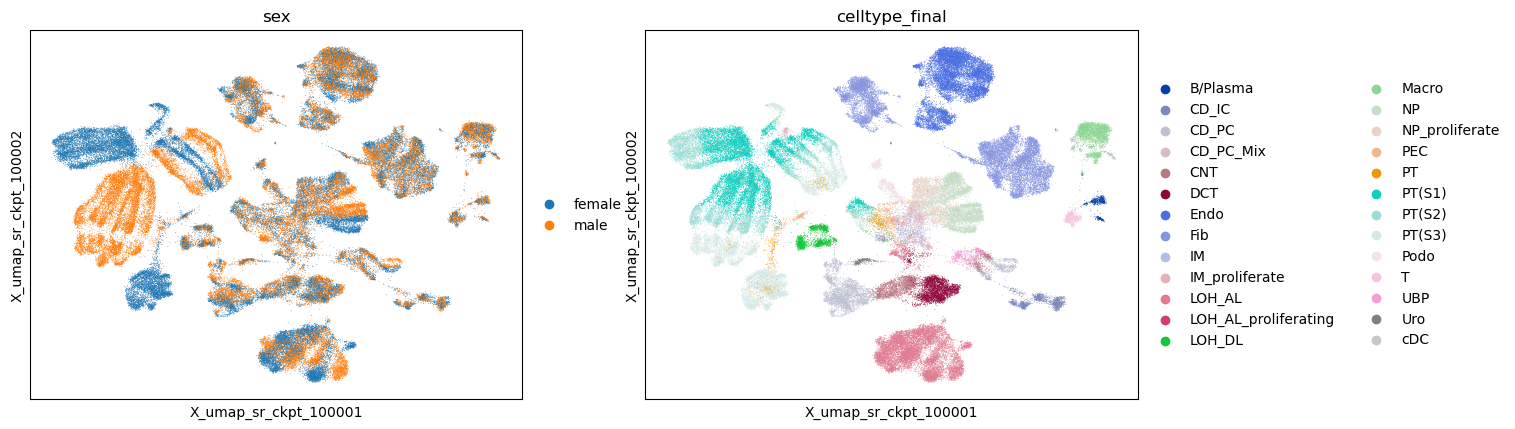

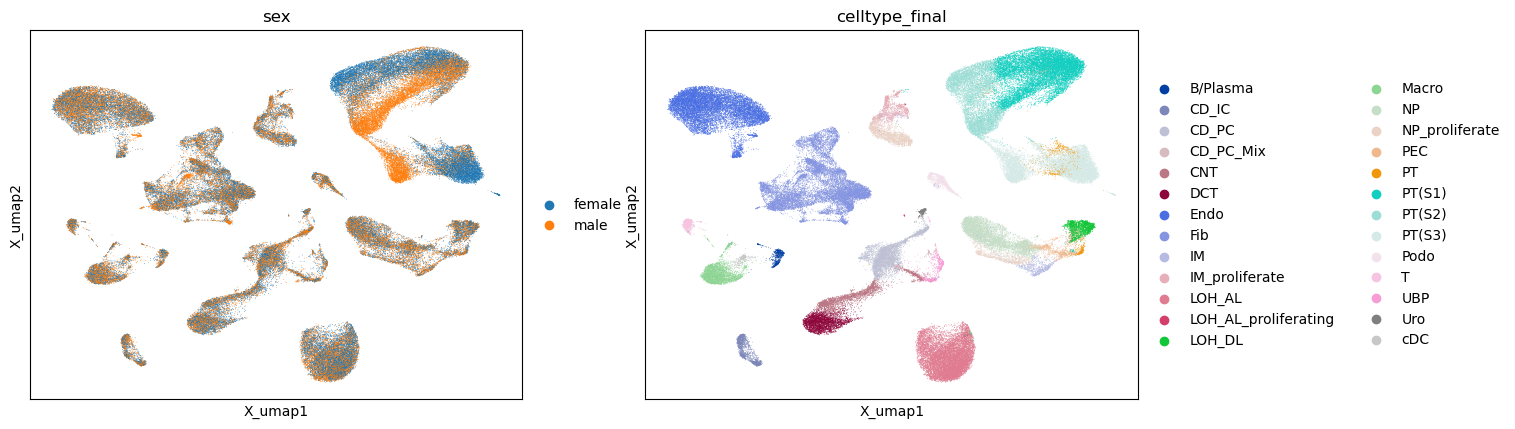

In [27]:
rna = mdata['rna_count']
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_2000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_4000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_6000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_8000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap_sr_ckpt_10000', color = ['sex','celltype_final'])
sc.pl.embedding(rna, basis = 'X_umap', color = ['sex','celltype_final'])


/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 64 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


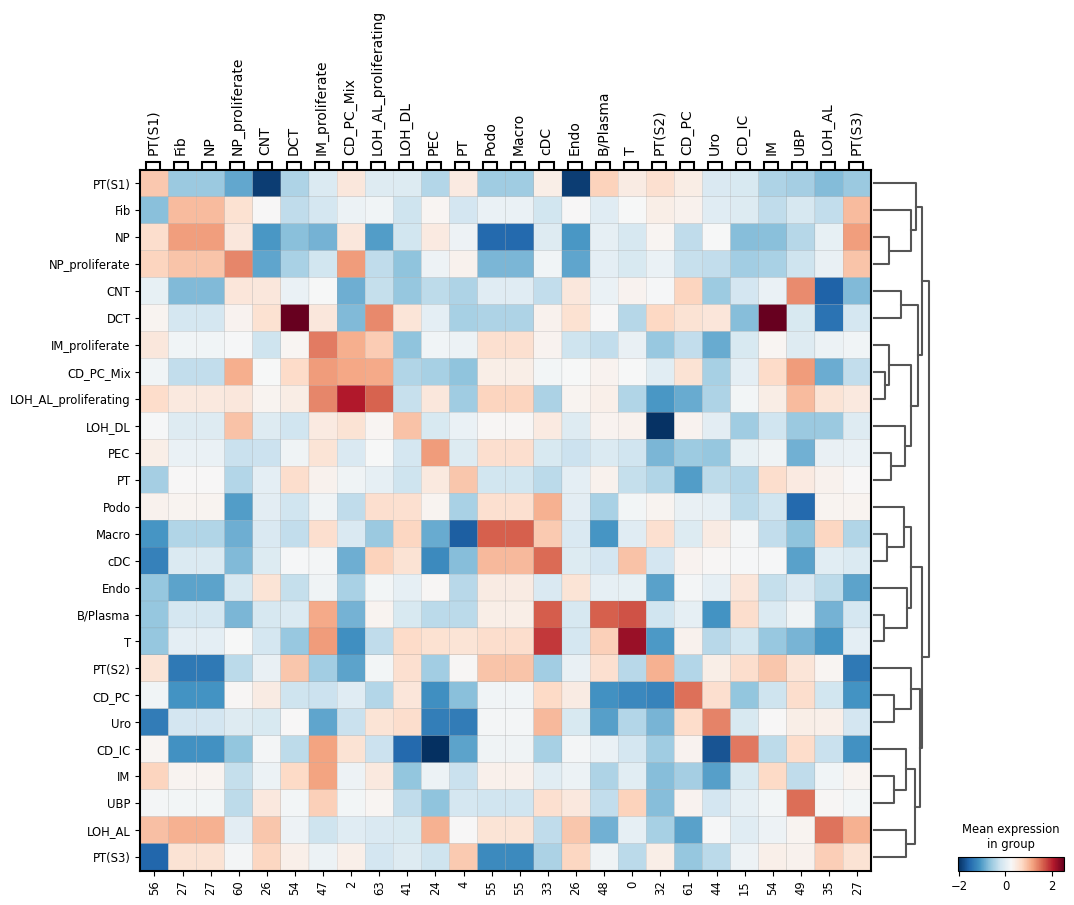

In [9]:
import anndata as ad

embed = rna.obsm['X_embed_sr_ckpt_10000'].copy()
adata = ad.AnnData(embed, obs = rna.obs.copy())
sc.pp.scale(adata)
sc.tl.rank_genes_groups(adata, groupby = 'celltype_final', mehod = 'logreg')
sc.pl.rank_genes_groups_matrixplot(adata, groupby = 'celltype_final', cmap = 'RdBu_r', n_genes = 1)


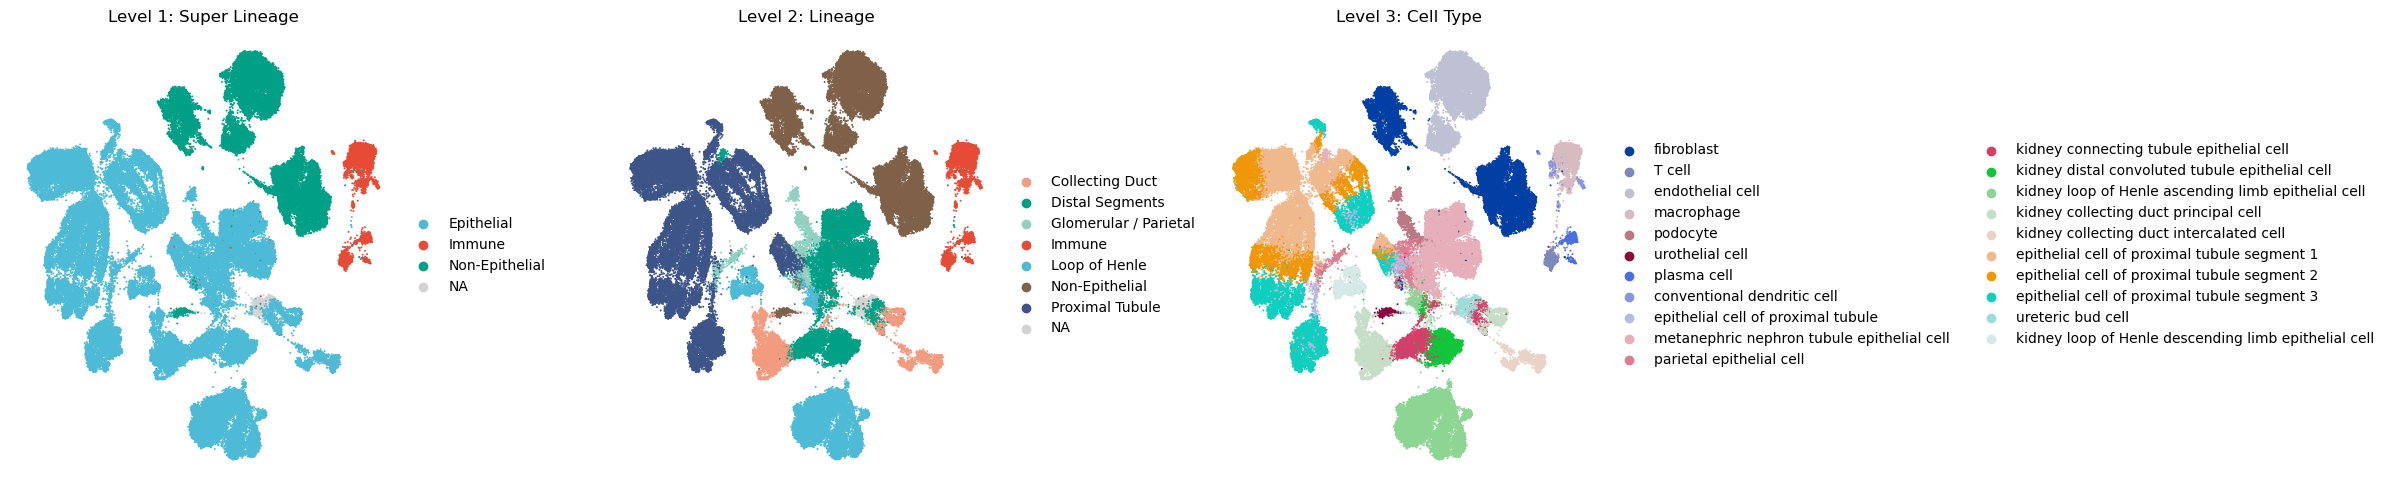

In [37]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import anndata as ad

# ============================================================
# 1. 定义层次映射
# ============================================================
lineage_map = {
    'T cell': 'Immune',
    'plasma cell': 'Immune',
    'macrophage': 'Immune',
    'conventional dendritic cell': 'Immune',

    'epithelial cell of proximal tubule': 'Proximal Tubule',
    'epithelial cell of proximal tubule segment 1': 'Proximal Tubule',
    'epithelial cell of proximal tubule segment 2': 'Proximal Tubule',
    'epithelial cell of proximal tubule segment 3': 'Proximal Tubule',

    'kidney loop of Henle ascending limb epithelial cell': 'Loop of Henle',
    'kidney loop of Henle descending limb epithelial cell': 'Loop of Henle',

    'kidney distal convoluted tubule epithelial cell': 'Distal Segments',
    'kidney connecting tubule epithelial cell': 'Distal Segments',
    'metanephric nephron tubule epithelial cell': 'Distal Segments',

    'kidney collecting duct principal cell': 'Collecting Duct',
    'kidney collecting duct intercalated cell': 'Collecting Duct',

    'podocyte': 'Glomerular / Parietal',
    'parietal epithelial cell': 'Glomerular / Parietal',

    'fibroblast': 'Non-Epithelial',
    'endothelial cell': 'Non-Epithelial',
    'urothelial cell': 'Non-Epithelial',
}

super_lineage_map = {
    'Immune': 'Immune',
    'Proximal Tubule': 'Epithelial',
    'Loop of Henle': 'Epithelial',
    'Distal Segments': 'Epithelial',
    'Collecting Duct': 'Epithelial',
    'Glomerular / Parietal': 'Epithelial',
    'Non-Epithelial': 'Non-Epithelial',
}

# ============================================================
# 2. 构建带层次标注的 AnnData
# ============================================================
embed = rna.obsm['X_embed_sr_ckpt_10000'].copy()
adata = ad.AnnData(embed, obs=rna.obs.copy())

adata.obs['cell_type'] = adata.obs['cell_type']
adata.obs['lineage'] = adata.obs['cell_type'].map(lineage_map)
adata.obs['super_lineage'] = adata.obs['lineage'].map(super_lineage_map)
adata.obsm['X_umap'] = rna.obsm['X_umap_sr_ckpt_10000']
# for key in rna.obsm:
#     adata.obsm[key] = rna.obsm[key].copy()

# ============================================================
# 3. 配色方案
# ============================================================
palette_super = {
    'Immune': '#E64B35',
    'Epithelial': '#4DBBD5',
    'Non-Epithelial': '#00A087',
}

palette_lineage = {
    'Immune': '#E64B35',
    'Proximal Tubule': '#3C5488',
    'Loop of Henle': '#4DBBD5',
    'Distal Segments': '#00A087',
    'Collecting Duct': '#F39B7F',
    'Glomerular / Parietal': '#91D1C2',
    'Non-Epithelial': '#7E6148',
}

palette_sub_lineage = {
    'Immune': '#E64B35',
    'Proximal Tubule': '#3C5488',
    'Loop of Henle': '#4DBBD5',
    'Distal Segments': '#00A087',
    'Collecting Duct': '#F39B7F',
    'Glomerular / Parietal': '#91D1C2',
    'Non-Epithelial': '#7E6148',
    'Proximal Tubule (fine)': '#B09F80',
}

# ============================================================
# 4. 三行 UMAP：super lineage → lineage → cell type
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

# Row 1: Super lineage (3 大类)
sc.pl.umap(adata, color='super_lineage', palette=palette_super,
           ax=axes[0], show=False, title='Level 1: Super Lineage',
           legend_loc='right margin', frameon=False, s=8)

# Row 2: Lineage (7 亚类)
sc.pl.umap(adata, color='lineage', palette=palette_lineage,
           ax=axes[1], show=False, title='Level 2: Lineage',
           legend_loc='right margin', frameon=False, s=8)

# Row 3: Fine cell type (20 种)
sc.pl.umap(adata, color='cell_type',
           ax=axes[2], show=False, title='Level 3: Cell Type',
           legend_loc='right margin', frameon=False, s=8)

plt.tight_layout()
plt.show()



/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


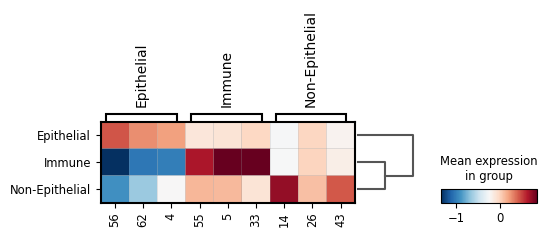

Epithelial ==========================


/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:639: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-package

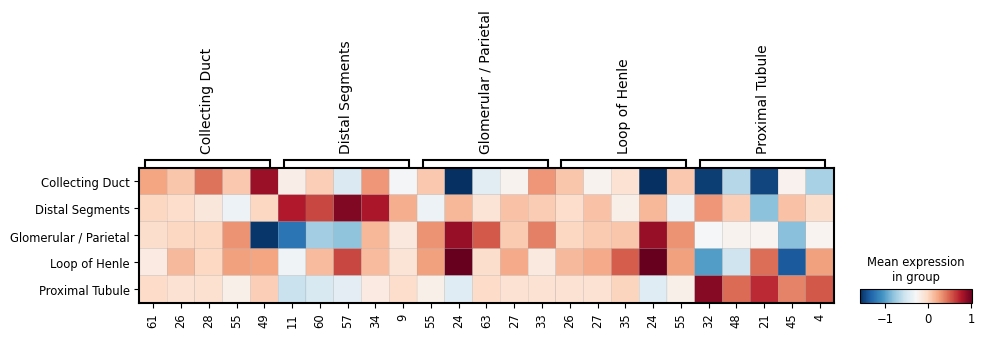

In [53]:

from seaborn.matrix import dendrogram


sc.tl.rank_genes_groups(adata, groupby = 'super_lineage', mehod = 'logreg')
sc.pl.rank_genes_groups_matrixplot(adata, groupby = 'super_lineage', cmap = 'RdBu_r', n_genes = 3)

for key in adata.obs.super_lineage.unique():
    print(f'{key} ==========================')
    idx = adata.obs.super_lineage == key 
    adata_new = adata[idx,:]
    sc.tl.rank_genes_groups(adata_new, groupby = 'lineage', mehod = 'logreg', dendrogram=False)
    sc.pl.rank_genes_groups_matrixplot(adata_new, groupby = 'lineage', cmap = 'RdBu_r', n_genes = 5,dendrogram=False)
    break   

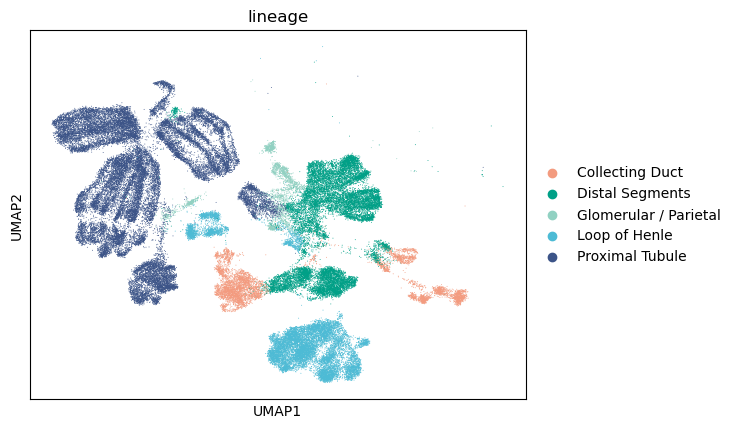

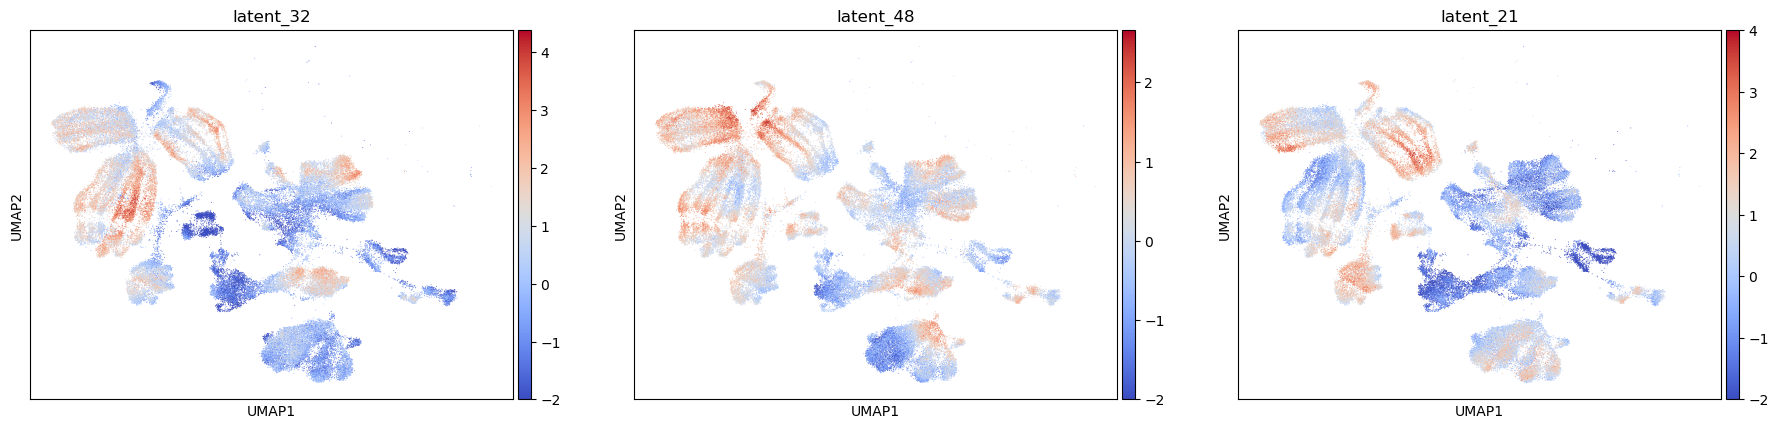

In [58]:
sc.pl.umap(adata_new, color = ['lineage'])
sc.pl.umap(adata_new, color = ['latent_32', 'latent_48', 'latent_21'], cmap = 'coolwarm',vmin = -2)